<a href="https://colab.research.google.com/github/pdf1802/f1-race-replay/blob/feature%2Fdata-analysis/analysis/notebooks/race_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastf1 xgboost shap umap-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00


In [2]:
import copy
import fastf1
import pandas as pd
import numpy as np
import joblib
import json
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports done")

✅ Imports done


In [3]:
#  Mount Drive, cache, load models
from google.colab import drive
drive.mount('/content/drive')

fastf1.Cache.enable_cache('/content/drive/MyDrive/f1_cache')

MODEL_DIR = '/content/drive/MyDrive/f1_models'

# Load models
LAP_MODEL    = joblib.load(f'{MODEL_DIR}/lap_time_model.pkl')
OVT_MODEL    = joblib.load(f'{MODEL_DIR}/overtaking_model.pkl')
TEAM_ENCODER = joblib.load(f'{MODEL_DIR}/team_encoder.pkl')

# Load compound map  {"SOFT": 0, "MEDIUM": 1, "HARD": 2}
with open(f'{MODEL_DIR}/compound_map.json') as f:
    COMPOUND_MAP = json.load(f)

COMPOUND_NAMES = {v: k for k, v in COMPOUND_MAP.items()}  # reverse: 0→"SOFT"

print("✅ Models loaded")
print(f"   Lap model    : {type(LAP_MODEL).__name__}")
print(f"   OVT model    : {type(OVT_MODEL).__name__}")
print(f"   Compound map : {COMPOUND_MAP}")

Mounted at /content/drive
✅ Models loaded
   Lap model    : XGBRegressor
   OVT model    : XGBClassifier
   Compound map : {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}


In [4]:
def encode_team(team_name: str) -> int:
    """Convert team name string to integer using the saved encoder."""
    try:
        return int(TEAM_ENCODER.transform([team_name])[0])
    except:
        return 0  # unknown team → default to 0

# Quick test
print(encode_team('Red Bull Racing'))  # should print an integer
print(encode_team('Ferrari'))

11
4


## Pace Factor Calculator

Derives team pace factors automatically from real FastF1 race data.
Averages across N races to avoid single-race outliers (DNFs, rain, SC).

Why N=5? One race is anecdote. Five races is a trend.
Fastest team = 1.000. Everyone else = their avg / fastest avg.
A factor of 1.008 means ~0.8% slower = ~0.76s/lap slower at 95s base.

This replaces hardcoded numbers — pace factors are always grounded
in real data for the chosen season.

In [5]:

def calculate_pace_factors(season: int, n_races: int = 5) -> dict:
    """
    Calculate pace factors from first N races of a season.
    Returns {team_name: factor} relative to fastest team (= 1.000).
    """
    team_times  = {}
    team_counts = {}

    for round_num in range(1, n_races + 1):
        try:
            session = fastf1.get_session(season, round_num, 'R')
            session.load(telemetry=False)

            laps     = session.laps.pick_quicklaps()
            laps     = laps[laps['LapTime'].notna()]
            race_avg = (laps.groupby('Team')['LapTime']
                            .mean()
                            .dt.total_seconds())

            for team, avg_time in race_avg.items():
                team_times[team]  = team_times.get(team, 0) + avg_time
                team_counts[team] = team_counts.get(team, 0) + 1

            print(f"  Round {round_num} ✅ loaded")

        except Exception as e:
            print(f"  Round {round_num} skipped: {e}")
            continue

    # Need at least 2 races to be a reliable estimate
    season_avg = {
        team: team_times[team] / team_counts[team]
        for team in team_times
        if team_counts[team] >= 2
    }

    fastest = min(season_avg.values())
    factors = {team: avg / fastest for team, avg in season_avg.items()}
    return factors

print("✅ calculate_pace_factors() defined")

✅ calculate_pace_factors() defined


## Derive Season Pace Factors

Call calculate_pace_factors() for the target season.
Change the season number here to simulate a different era.

2023 → Red Bull dominant (VER won 19/22 races)
2024 → McLaren/Red Bull/Ferrari close fight
2025 → McLaren dominant

In [6]:
# Cell 3b — Derive pace factors from real data
SEASON = 2023   # ← change this to simulate different eras

print(f"Loading {SEASON} pace factors from first 5 races...\n")
pace_factors = calculate_pace_factors(SEASON, n_races=5)

print(f"\n{SEASON} pace factors (fastest team = 1.000):")
for team, factor in sorted(pace_factors.items(), key=lambda x: x[1]):
    gap_per_lap = (factor - 1.0) * 95.0
    print(f"  {team:<20} {factor:.4f}  (+{gap_per_lap:.2f}s/lap)")

Loading 2023 pace factors from first 5 races...



core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

  Round 1 ✅ loaded


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  Round 2 ✅ loaded


...

  Round 3 ✅ loaded


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  Round 4 ✅ loaded


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  Round 5 ✅ loaded

2023 pace factors (fastest team = 1.000):
  Red Bull Racing      1.0000  (+0.00s/lap)
  Aston Martin         1.0065  (+0.61s/lap)
  Ferrari              1.0070  (+0.66s/lap)
  Mercedes             1.0073  (+0.69s/lap)
  Alpine               1.0109  (+1.04s/lap)
  Haas F1 Team         1.0136  (+1.29s/lap)
  McLaren              1.0138  (+1.31s/lap)
  AlphaTauri           1.0164  (+1.56s/lap)
  Alfa Romeo           1.0173  (+1.64s/lap)
  Williams             1.0178  (+1.69s/lap)


## Race Configuration

RACE_CONFIG uses the pace_factors derived in Cell 3b — never hardcoded.
Change SEASON in Cell 3b and re-run 3b + 3c to simulate a different era.

In [7]:

RACE_CONFIG = {
    'circuit'         : 'Bahrain',
    'total_laps'      : 57,
    'track_temp'      : 35.0,
    'air_temp'        : 28.0,
    'rainfall'        : 0,
    'sc_prob_per_lap' : 0.04,
    'pace_factors'    : pace_factors,   # ← derived from Cell 3b, never hardcoded
}

STARTING_GRID = [
    {'driver': 'VER', 'team': 'Red Bull Racing', 'position': 1, 'compound': 0, 'tyre_age': 1},
    {'driver': 'LEC', 'team': 'Ferrari',         'position': 2, 'compound': 0, 'tyre_age': 1},
    {'driver': 'SAI', 'team': 'Ferrari',         'position': 3, 'compound': 0, 'tyre_age': 1},
    {'driver': 'PER', 'team': 'Red Bull Racing', 'position': 4, 'compound': 0, 'tyre_age': 1},
    {'driver': 'NOR', 'team': 'McLaren',         'position': 5, 'compound': 0, 'tyre_age': 1},
    {'driver': 'ALO', 'team': 'Aston Martin',    'position': 6, 'compound': 0, 'tyre_age': 1},
]

STRATEGIES = {
    'VER': [(15, 1), (40, 2)],
    'LEC': [(16, 1), (41, 2)],
    'SAI': [(17, 1), (39, 2)],
    'PER': [(14, 1), (38, 2)],
    'NOR': [(18, 1), (40, 2)],
    'ALO': [(19, 1), (42, 2)],
}

print("✅ Race config set —", RACE_CONFIG['circuit'],
      RACE_CONFIG['total_laps'], "laps |",
      f"Season {SEASON} pace factors loaded")

✅ Race config set — Bahrain 57 laps | Season 2023 pace factors loaded


In [8]:
# What team names did the encoder see during training?
print(TEAM_ENCODER.classes_)

['Alfa Romeo' 'AlphaTauri' 'Alpine' 'Aston Martin' 'Ferrari'
 'Haas F1 Team' 'Kick Sauber' 'McLaren' 'Mercedes' 'RB' 'Racing Bulls'
 'Red Bull Racing' 'Williams']


##  DriverState Dataclass

A dataclass is a typed, structured object for holding state.
Safer and cleaner than a plain dictionary — wrong keys are caught
immediately, and methods like next_pit() live on the object itself.

Each DriverState tracks one driver through the race:
- position, compound, tyre_age → updated every lap
- race_time → cumulative seconds, how we determine final standings
- strategy → list of (pit_lap, new_compound) tuples
- next_pit() → returns the next upcoming stop, or None

Design rule: State holds data. Logic lives in the `step` function .
Never put simulation logic inside the dataclass.

In [9]:
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

@dataclass
class DriverState:
    driver:       str
    team_encoded: int
    team_name:    str        # ← ADD THIS
    position:     int
    compound:     int
    tyre_age:     int
    race_time:    float = 0.0
    laps_done:    int   = 0
    retired:      bool  = False
    strategy:     List[Tuple[int, int]] = field(default_factory=list)

    def next_pit(self) -> Optional[Tuple[int,int]] :
        """Next scheduled pit stop(lap, new_compound), or None."""
        upcoming= [(lap,comp) for lap,comp in self.strategy if lap > self.laps_done]

        return upcoming[0] if upcoming else None

    def __repr__ (self):
        compound_name = {0:'SOFT', 1:'MEDIUM', 2:'HARD'}.get(self.compound, '?')
        return (f"P{self.position} {self.driver} | "
                    f"{compound_name} age {self.tyre_age} | "
                    f"race time {self.race_time:.1f}s")

In [26]:
#Sanity check: build the starting grid as DriverState objects
drivers = []
for entry in STARTING_GRID:
    ds = DriverState(
        driver       = entry['driver'],
        team_encoded = encode_team(entry['team']),
        team_name    = entry['team'],
        position     = entry['position'],
        compound     = entry['compound'],
        tyre_age     = entry['tyre_age'],
        strategy     = STRATEGIES[entry['driver']]
    )
    drivers.append(ds)

# Print the grid and verify next_pit() works
for d in drivers:
    print(d)
    print(f"   → next pit: {d.next_pit()}")
    print()

P1 VER | SOFT age 1 | race time 0.0s
   → next pit: (15, 1)

P2 LEC | SOFT age 1 | race time 0.0s
   → next pit: (16, 1)

P3 SAI | SOFT age 1 | race time 0.0s
   → next pit: (17, 1)

P4 PER | SOFT age 1 | race time 0.0s
   → next pit: (14, 1)

P5 NOR | SOFT age 1 | race time 0.0s
   → next pit: (18, 1)

P6 ALO | SOFT age 1 | race time 0.0s
   → next pit: (19, 1)



##  Lap Time Prediction

Calls the saved XGBoost model (Module 1) to predict LapDelta for
a given driver on a given lap. LapDelta = seconds above that
driver's personal best. Added back to a BASE_LAPTIME to get
an absolute lap time.

Inputs come directly from the DriverState object — compound,
tyre_age, team_encoded, laps_done — plus race-level constants
from RACE_CONFIG.

Small Gaussian noise (σ=0.15s) is added to each prediction.
This is what makes each Monte Carlo run slightly different —
without it every run produces identical results.

In [11]:
# Bahrain 2024 average lap ~95s, we use it as our base

BASE_LAPTIME = 95.0

def predict_lap_time_batch(drivers: list, lap: int, config: dict) -> dict:
    """
    Predict lap times for ALL drivers in a single model call.
    Returns dict of {driver: lap_time}.
    Much faster than calling predict() once per driver.
    """
    active = [d for d in drivers if not d.retired]
    if not active:
        return {}

    # Build one DataFrame with all drivers as rows
    rows = [{
        'CompoundEncoded' : d.compound,
        'TyreLife'        : d.tyre_age,
        'TeamEncoded'     : d.team_encoded,
        'LapNumber'       : lap,
        'TrackTemp'       : config['track_temp'],
        'AirTemp'         : config['air_temp'],
        'RainfallEncoded' : config['rainfall'],
    } for d in active]

    features = pd.DataFrame(rows)
    deltas   = LAP_MODEL.predict(features)  # one call, N predictions

    # Pace factor — multiplier per team to adjust for car performance era
    factors   = np.array([
        config['pace_factors'].get(d.team_name, 1.0)
        for d in active
    ])

    noise     = np.random.normal(0, 0.15, size=len(active))
    lap_times = (BASE_LAPTIME + deltas) * factors + noise  # ← factors applied here

    return {d.driver: t for d, t in zip(active, lap_times)}


## Pit Stop Logic

Handles pit stop execution. Called every lap for every driver.

Two things happen during a pit stop:
1. Tyre change — compound and tyre_age update on the DriverState
2. Time loss — a pit stop costs ~22-24s in Bahrain (stationary time + pit lane delta vs racing line). We sample this from a normal
   distribution to reflect real variance between stops.

A pit stop is "due" when laps_done == the next scheduled pit lap.
After pitting, the strategy list still holds future stops —
next_pit() will return the following one automatically.

No position changes happen here — pit stop position effects are
handled by the overtaking logic in Cell 7. Here we only handle
time and tyre state.

In [12]:
# Bahrain pit loss: ~22s stationary + ~1.5s pit lane delta
# Real 2024 data: fastest stops ~2.4s stationary, average ~2.8s
PIT_LOSS_MEAN = 23.5   # seconds lost vs staying out
PIT_LOSS_STD  = 0.8    # variance between stops

def apply_pit_stop(driver: DriverState, lap: int) -> tuple[bool, float]:
    """
    Check if driver pits this lap. If yes, execute it.
    Returns (did_pit, time_cost).
    Time cost is 0.0 if no pit stop this lap.
    """
    next_stop = driver.next_pit()

    # No more stops scheduled
    if next_stop is None:
        return False, 0.0

    pit_lap, new_compound = next_stop

    # Not this lap
    if pit_lap != lap:
        return False, 0.0

    # Execute pit stop
    driver.compound  = new_compound
    driver.tyre_age  = 1  # fresh tyre
    time_cost = np.random.normal(PIT_LOSS_MEAN, PIT_LOSS_STD)

    return True, time_cost

In [13]:
# --- Sanity check ---
# Clone PER (pits on lap 14) and simulate laps 13, 14, 15
print("=== PIT STOP SANITY CHECK — PER ===\n")

per = drivers[3]  # PER, strategy [(14, 1), (38, 2)]
print(f"Before: {per}")
print(f"Next pit: {per.next_pit()}\n")

for lap in [13, 14, 15]:
    # We need a fresh copy each iteration for a clean test
    import copy
    per_test = copy.deepcopy(per)
    per_test.laps_done = lap - 1  # simulate being on this lap

    did_pit, cost = apply_pit_stop(per_test, lap)

    if did_pit:
        print(f"Lap {lap}: PIT ✅ | cost={cost:.2f}s | "
              f"new compound={COMPOUND_NAMES[per_test.compound]} | "
              f"tyre_age={per_test.tyre_age}")
    else:
        print(f"Lap {lap}: no stop | "
              f"compound={COMPOUND_NAMES[per_test.compound]} | "
              f"tyre_age={per_test.tyre_age}")

=== PIT STOP SANITY CHECK — PER ===

Before: P4 PER | SOFT age 1 | race time 0.0s
Next pit: (14, 1)

Lap 13: no stop | compound=SOFT | tyre_age=1
Lap 14: PIT ✅ | cost=24.25s | new compound=MEDIUM | tyre_age=1
Lap 15: no stop | compound=SOFT | tyre_age=1


## Overtake Logic

Calls the saved Module 2 classifier to decide whether an overtake
attempt succeeds on a given lap.

An overtake attempt only happens when two conditions are met:
1. A faster car is within DRS range (gap < 1.0s at the detection point)
2. The car ahead has a tyre disadvantage (older or softer compound)

If both conditions are met, we ask the model: given this gap, this
tyre delta, these compounds — what is the probability of an overtake?
Then we sample from that probability (np.random.random() < prob).

This is the Monte Carlo element in the overtake logic — the same
scenario might result in an overtake in run 600 but not in run 601.
Positions are then re-sorted by cumulative race_time, not by
on-track gaps. This is a simplification — we are not modelling
physical track position, only time gaps.

In [27]:
DRS_WINDOW = 1.0

def check_overtakes(drivers: list) -> list:
    """
    For each consecutive pair of drivers, check if the following car
    overtakes the car ahead. Max 1 position gain per driver per lap.
    Returns drivers sorted by updated positions.
    """
    # Sort by race_time to get the "true pace order"
    pace_order = sorted(drivers, key=lambda d: d.race_time)



    for i in range(1, len(pace_order)):
        car_behind = pace_order[i]
        car_ahead  = pace_order[i - 1]

        if car_behind.retired or car_ahead.retired:
            continue

        gap = car_behind.race_time - car_ahead.race_time

        # Only attempt overtake if within DRS window
        if gap > DRS_WINDOW:
            continue

        tyre_delta = car_ahead.tyre_age - car_behind.tyre_age

        features = pd.DataFrame([{
            'GapAhead'             : gap,
            'TyreDelta'            : tyre_delta,
            'CompoundEncoded'      : car_behind.compound,
            'CompoundAheadEncoded' : car_ahead.compound,
            'TyreLife'             : car_behind.tyre_age,
            'TyreLifeAhead'        : car_ahead.tyre_age,
            'LapNumber'            : car_behind.laps_done,
            'Position'             : car_behind.position,
        }])

        prob = OVT_MODEL.predict_proba(features)[0][1]

        if np.random.random() < prob:
            # Swap positions — but only if it's a 1-position gain
            if car_ahead.position == car_behind.position - 1:
                car_behind.position, car_ahead.position = (
                    car_ahead.position, car_behind.position
                )
                pace_order[i], pace_order[i-1] = pace_order[i-1], pace_order[i]

    return sorted(pace_order, key=lambda d: d.position)

In [15]:
# Fix the test — set laps_done to lap 25 (mid-race, realistic)
test_drivers = copy.deepcopy(drivers)

test_drivers[0].race_time = 1000.0  # VER ahead
test_drivers[1].race_time = 1000.5  # LEC 0.5s behind
test_drivers[0].tyre_age  = 25      # VER on old tyres
test_drivers[1].tyre_age  = 5       # LEC on fresh tyres
test_drivers[0].laps_done = 25      # ← add this
test_drivers[1].laps_done = 25      # ← and this

print("=== OVERTAKE SANITY CHECK (fixed) ===")
print(f"Before: VER P{test_drivers[0].position} | LEC P{test_drivers[1].position}")
print(f"Gap: 0.5s | VER tyre age 25 | LEC tyre age 5 | Lap 25\n")

overtakes = 0
for _ in range(20):
    trial = copy.deepcopy(test_drivers)
    result = check_overtakes(trial)
    if result[0].driver == 'LEC':
        overtakes += 1

print(f"LEC overtook VER in {overtakes}/20 trials ({overtakes*5}% of attempts)")

=== OVERTAKE SANITY CHECK (fixed) ===
Before: VER P1 | LEC P2
Gap: 0.5s | VER tyre age 25 | LEC tyre age 5 | Lap 25

LEC overtook VER in 10/20 trials (50% of attempts)


## Full Lap Loop (simulate_race)

The core simulation engine. Runs one complete race from lap 1 to lap N.

Each lap, for every driver:
1. predict_lap_time()  → how long this lap takes (Module 1)
2. apply_pit_stop()    → did they pit? add time cost (rule-based)
3. tyre_age += 1       → tyre gets one lap older
4. laps_done += 1      → lap counter increments
5. race_time += lap_t  → cumulative time grows

After all drivers complete the lap:
6. check_overtakes()   → did anyone get past? (Module 2)
7. safety car check    → random coin flip, slows everyone equally

Final standings = sort by race_time (lowest = winner).

This function runs ONE race. The Monte Carlo wrapper
calls it 1,000 times.

In [16]:
SAFETY_CAR_DELTA = 30.0 #seconds lost when SC depolyed (everyone slows equally)

def simulate_race(config: dict,grid: list) -> list[DriverState]:
  """
  Simulate one full race. Returns drivers sorted by final position.
  """

  import copy
  drivers= copy.deepcopy(grid)

  sc_active= False
  sc_laps_remaining= 0

  for lap in range(1,config['total_laps']+1):

    #Safety car logic
    if sc_active:
      sc_laps_remaining -=1
      if sc_laps_remaining <=0:
        sc_active=False
    elif np.random.random() < config['sc_prob_per_lap']:
      sc_active = True
      sc_laps_remaining= 4 #SC typically lasts ~4 laps in F1

    #Per driver :lap time+ pit stop
    lap_times = predict_lap_time_batch(drivers,lap,config)
    for driver in drivers:
      if driver.retired:
        continue


      #1. Predict lap time
      lap_time= lap_times[driver.driver]

      #2. Safety car - everyone lloses time, gaps compress
      if sc_active:
        lap_time += SAFETY_CAR_DELTA

      #3.Pit stop check
      did_pit, pit_cost= apply_pit_stop(driver,lap)
      if did_pit:
        lap_time += pit_cost

      #4. Update state
      driver.race_time += lap_time
      driver.tyre_age +=1
      driver.laps_done =lap

    #After all drivers complete this lap
    #5. Check overtakes(only on green flag laps)
    if not sc_active:
      drivers= check_overtakes(drivers)


  #Final standings - sort by cumulative race time
  drivers= sorted(drivers, key=lambda d: d.race_time)
  for i,d in enumerate(drivers):
    d.position = i+1

  return drivers

In [17]:
# --- Sanity check: run one race ---
print("Running one race simulation...\n")
result = simulate_race(RACE_CONFIG, drivers)

print("=" * 40)
print(f"{'POS':<5} {'DRIVER':<8} {'RACE TIME':>12}  {'FINAL TYRE':<10}")
print("=" * 40)
for d in result:
    compound_name = COMPOUND_NAMES.get(d.compound, '?')
    print(f"P{d.position:<4} {d.driver:<8} {d.race_time:>12.1f}s  {compound_name}")
print("=" * 40)

Running one race simulation...

POS   DRIVER      RACE TIME  FINAL TYRE
P1    VER            5782.1s  HARD
P2    PER            5784.4s  HARD
P3    LEC            5819.3s  HARD
P4    SAI            5820.9s  HARD
P5    ALO            5841.5s  HARD
P6    NOR            5853.8s  HARD


##  Monte Carlo Wrapper

Calls simulate_race() N times and aggregates the results into
win probabilities per driver.

This is the shortest cell in the notebook but the most important
conceptually. The complexity is entirely inside simulate_race().
The wrapper just runs it many times and counts outcomes.

n_runs=1000 gives stable probabilities (±2-3% variance between
runs of the wrapper itself). n_runs=100 is faster for testing
but probabilities will be noisy.

In [18]:
from collections import Counter

def monte_carlo(config:dict, grid:list,n_runs:int = 1000)-> dict:
  """
  Run simulate_race() n_runs times.
  Returns win counts and win probabilty per driver.
  """

  win_counts=Counter()

  for i in range(n_runs):
    result = simulate_race(config, grid)
    winner = result[0].driver
    win_counts[winner] += 1

    #Progress indicator evey 100 runs
    if(i+1) % 100 ==0:
      print(f"  {i + 1}/{n_runs} simulations done...")

  #Convert counts to probabilities
  win_probs= {
      driver: count / n_runs
      for driver, count in win_counts.most_common()
  }

  return win_probs


In [19]:
# Speed fix — disable XGBoost feature validation on every prediction
# We already verified features are correct, this check is redundant overhead
LAP_MODEL.get_booster().set_param('nthread', 1)

import os
os.environ['OMP_NUM_THREADS'] = '1'

In [23]:
print("🏎️  Running 1000 race simulations...\n")
probs = monte_carlo(RACE_CONFIG, drivers, n_runs=1000)

print("\n" + "=" * 40)
print(f"{'DRIVER':<10} {'WIN PROB':>10}  {'BAR'}")
print("=" * 40)
for driver, prob in probs.items():
    bar = "█" * int(prob * 40)
    print(f"{driver:<10} {prob*100:>9.1f}%  {bar}")
print("=" * 40)

🏎️  Running 1000 race simulations...

  100/1000 simulations done...
  200/1000 simulations done...
  300/1000 simulations done...
  400/1000 simulations done...
  500/1000 simulations done...
  600/1000 simulations done...
  700/1000 simulations done...
  800/1000 simulations done...
  900/1000 simulations done...
  1000/1000 simulations done...

DRIVER       WIN PROB  BAR
VER             62.2%  ████████████████████████
PER             37.8%  ███████████████


##Visualisation

Two charts from the Monte Carlo results:
1. Win probability bar chart — who wins and how often
2. Single race position trace — how positions evolved lap by lap

These are the outputs you'd show in a presentation or portfolio.
The bar chart is the Monte Carlo summary. The trace shows one
example race to illustrate how the simulation plays out.

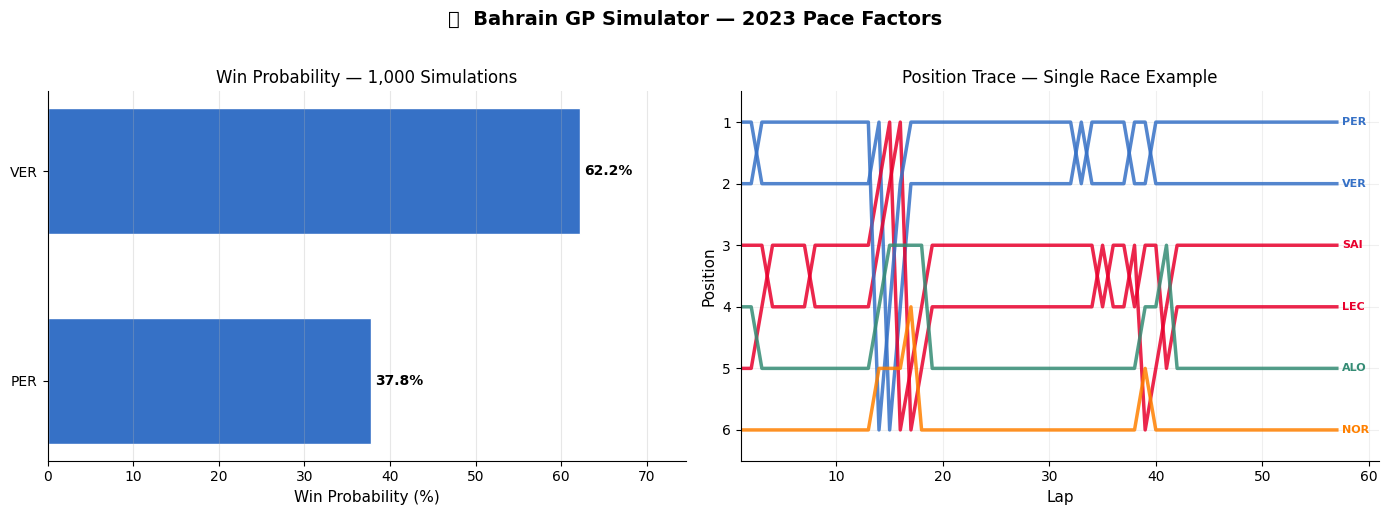

✅ Chart saved as bahrain_simulation.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import copy

# ── Colour palette — one per driver ──────────────────────────────────────────
DRIVER_COLOURS = {
    'VER': '#3671C6',   # Red Bull blue
    'PER': '#3671C6',
    'LEC': '#E8002D',   # Ferrari red
    'SAI': '#E8002D',
    'NOR': '#FF8000',   # McLaren orange
    'ALO': '#358C75',   # Aston Martin green
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'🏎️  Bahrain GP Simulator — {SEASON} Pace Factors',
             fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Win probability bar chart ───────────────────────────────────────
ax1 = axes[0]
drivers_list = list(probs.keys())
win_pcts     = [probs[d] * 100 for d in drivers_list]
colours      = [DRIVER_COLOURS.get(d, '#888888') for d in drivers_list]

bars = ax1.barh(drivers_list[::-1], win_pcts[::-1],
                color=colours[::-1], edgecolor='white', height=0.6)

for bar, pct in zip(bars, win_pcts[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Win Probability (%)', fontsize=11)
ax1.set_title(f'Win Probability — 1,000 Simulations', fontsize=12)
ax1.set_xlim(0, max(win_pcts) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3)
# ── Chart 2: Position trace — single race ────────────────────────────────────
ax2 = axes[1]

# Run one race and track positions every lap
trace_drivers = copy.deepcopy(drivers)
sc_active         = False
sc_laps_remaining = 0
position_history  = {d.driver: [] for d in trace_drivers}

for lap in range(1, RACE_CONFIG['total_laps'] + 1):
    if sc_active:
        sc_laps_remaining -= 1
        if sc_laps_remaining <= 0:
            sc_active = False
    elif np.random.random() < RACE_CONFIG['sc_prob_per_lap']:
        sc_active         = True
        sc_laps_remaining = 4

    lap_times = predict_lap_time_batch(trace_drivers, lap, RACE_CONFIG)
    for driver in trace_drivers:
        if driver.retired:
            continue
        lap_time = lap_times[driver.driver]
        if sc_active:
            lap_time += SAFETY_CAR_DELTA
        did_pit, pit_cost = apply_pit_stop(driver, lap)
        if did_pit:
            lap_time += pit_cost
        driver.race_time += lap_time
        driver.tyre_age  += 1
        driver.laps_done  = lap

    if not sc_active:
        trace_drivers = check_overtakes(trace_drivers)

    sorted_drivers = sorted(trace_drivers, key=lambda d: d.race_time)
    for i, d in enumerate(sorted_drivers):
        position_history[d.driver].append(i + 1)

laps = list(range(1, RACE_CONFIG['total_laps'] + 1))
for driver, positions in position_history.items():
    colour = DRIVER_COLOURS.get(driver, '#888888')
    ax2.plot(laps, positions,
             label=driver, color=colour,
             linewidth=2.5, alpha=0.85)
    # Label at end of line
    ax2.text(laps[-1] + 0.5, positions[-1],
             driver, va='center', fontsize=8,
             color=colour, fontweight='bold')

ax2.set_xlabel('Lap', fontsize=11)
ax2.set_ylabel('Position', fontsize=11)
ax2.set_title('Position Trace — Single Race Example', fontsize=12)
ax2.set_ylim(6.5, 0.5)          # invert: P1 at top
ax2.set_yticks(range(1, 7))
ax2.set_xlim(1, RACE_CONFIG['total_laps'] + 4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('bahrain_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as bahrain_simulation.png")